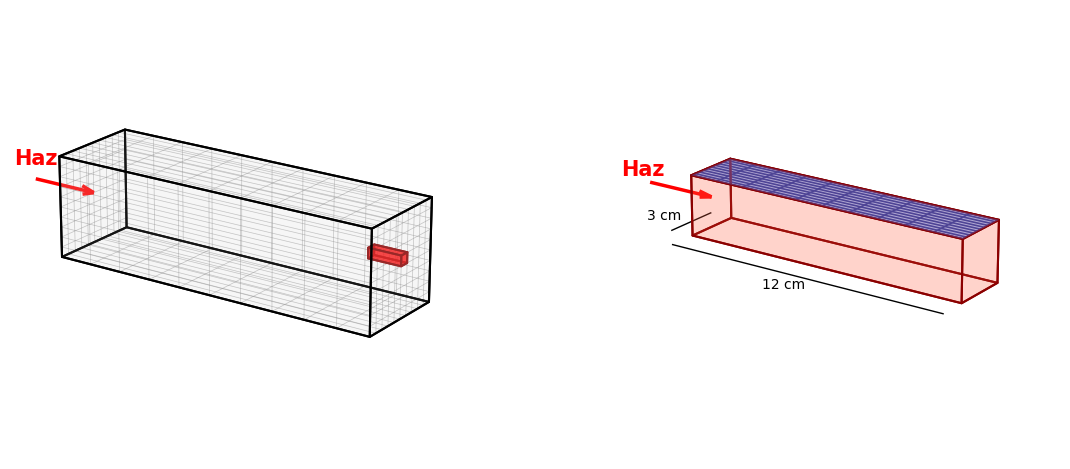

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def draw_solid_box(ax, origin, size, facecolor, edgecolor='black', alpha=0.3, linewidth=1.0):
    """Dibuja una caja 3D con caras sólidas y semitransparentes."""
    x, y, z = origin
    dx, dy, dz = size
    
    # Definir los 8 vértices
    v = np.array([[x, y, z], [x+dx, y, z], [x+dx, y+dy, z], [x, y+dy, z],
                  [x, y, z+dz], [x+dx, y, z+dz], [x+dx, y+dy, z+dz], [x, y+dy, z+dz]])
    
    # Definir las 6 caras
    faces = [
        [v[0], v[1], v[5], v[4]], [v[1], v[2], v[6], v[5]], 
        [v[2], v[3], v[7], v[6]], [v[3], v[0], v[4], v[7]], 
        [v[0], v[1], v[2], v[3]], [v[4], v[5], v[6], v[7]]  
    ]
    
    poly3d = Poly3DCollection(faces, alpha=alpha, facecolors=facecolor, edgecolors=edgecolor, linewidths=linewidth)
    ax.add_collection3d(poly3d)

# Ajustamos la proporción para que ocupe bien el ancho de un folio sin tanto margen vertical
fig = plt.figure(figsize=(12, 4.5), facecolor='white')

# ==========================================
# SUBPLOT 1: CALORÍMETRO MACRO TUMBADO
# ==========================================
ax1 = fig.add_subplot(121, projection='3d')

# Dimensiones en el plot: Eje X será nuestro Z físico (120 cm). Y y Z serán X e Y físicos (30 cm)
X_max, Y_max, Z_max = 120, 30, 30
dx, dy, dz = 12, 3, 3

ax1.set_xlim([-10, X_max+10]); ax1.set_ylim([0, Y_max]); ax1.set_zlim([0, Z_max])

# Dibujamos el macro-volumen sólido
draw_solid_box(ax1, (0,0,0), (X_max, Y_max, Z_max), facecolor='lightgray', alpha=0.1, linewidth=1.5)

# Dibujamos la cuadrícula EXCLUSIVAMENTE en las caras exteriores (10x10x10)
for y in range(0, Y_max + 1, dy):
    for z in [0, Z_max]: ax1.plot3D([0, X_max], [y, y], [z, z], color='gray', alpha=0.5, linewidth=0.5)
for z in range(0, Z_max + 1, dz):
    for y in [0, Y_max]: ax1.plot3D([0, X_max], [y, y], [z, z], color='gray', alpha=0.5, linewidth=0.5)
for x in range(0, X_max + 1, dx):
    for z in [0, Z_max]: ax1.plot3D([x, x], [0, Y_max], [z, z], color='gray', alpha=0.5, linewidth=0.5)
for z in range(0, Z_max + 1, dz):
    for x in [0, X_max]: ax1.plot3D([x, x], [0, Y_max], [z, z], color='gray', alpha=0.5, linewidth=0.5)
for x in range(0, X_max + 1, dx):
    for y in [0, Y_max]: ax1.plot3D([x, x], [y, y], [0, Z_max], color='gray', alpha=0.5, linewidth=0.5)
for y in range(0, Y_max + 1, dy):
    for x in [0, X_max]: ax1.plot3D([x, x], [y, y], [0, Z_max], color='gray', alpha=0.5, linewidth=0.5)

# Resaltamos un cubelet individual en rojo
draw_solid_box(ax1, (108, 15, 15), (dx, dy, dz), facecolor='red', edgecolor='darkred', alpha=0.6, linewidth=1.5)

# Flecha del Haz de partículas
ax1.quiver(-25, 15, 15, 25, 0, 0, color='red', arrow_length_ratio=0.2, linewidth=2.5)
ax1.text(-24, 14, 20, "Haz", color='red', fontsize=15, ha='center', weight='bold')

ax1.set_box_aspect([4, 1, 1]) 
ax1.view_init(elev=20, azim=-55) 
ax1.axis('off')


# ==========================================
# SUBPLOT 2: EL CUBELET Y LOS SENSORES
# ==========================================
ax2 = fig.add_subplot(122, projection='3d')

ax2.set_xlim([-2, dx+2]); ax2.set_ylim([-1, dy+1]); ax2.set_zlim([-1, dz+1])

# Dibujamos el cubelet sólido (cristal)
draw_solid_box(ax2, (0,0,0), (dx, dy, dz), facecolor='tomato', edgecolor='darkred', alpha=0.15, linewidth=1.5)

# Flecha del Haz
ax2.quiver(-3, 1.5, 1.5, 3, 0, 0, color='red', arrow_length_ratio=0.2, linewidth=2.5)
ax2.text(-3, 1, 2, "Haz", color='red', fontsize=15, ha='center', weight='bold')


# --- MATRIZ FÍSICA DE SENSORES 10x10 EN LA CARA SUPERIOR (z=dz) ---

# 1. Coloreamos la cara de arriba para simular la placa de los fotodetectores
top_plane = [[ [0,0,dz], [dx,0,dz], [dx,dy,dz], [0,dy,dz] ]]
ax2.add_collection3d(Poly3DCollection(top_plane, alpha=0.4, facecolors='royalblue', edgecolors='none'))

# 2. Dibujamos las líneas físicas de las celdas (11 líneas para formar 10 celdas)
x_lines = np.linspace(0, dx, 11)
y_lines = np.linspace(0, dy, 11)

for x_val in x_lines:
    ax2.plot3D([x_val, x_val], [0, dy], [dz, dz], color='midnightblue', linewidth=1.2)
for y_val in y_lines:
    ax2.plot3D([0, dx], [y_val, y_val], [dz, dz], color='midnightblue', linewidth=1.2)


# --- COTAS DE MEDIDA ---
ax2.plot3D([0, 12], [-1.5 , -1.5], [0, 0], color='black', linewidth=1)
ax2.text(6, -3, 0, "12 cm", ha='center')
ax2.plot3D([-1, -1], [0, 3], [0, 0], color='black', linewidth=1)
ax2.text(-1.5, 1.5, 0, "3 cm", ha='right')

ax2.set_box_aspect([4, 1, 1])
ax2.view_init(elev=20, azim=-55)
ax2.axis('off')

# Eliminamos el espacio en blanco forzando los márgenes
plt.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0)
plt.savefig("geometria_cubelets.png", dpi=300, bbox_inches='tight', pad_inches=0.05)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def draw_solid_box(ax, origin, size, facecolor, edgecolor='black', alpha=0.3, linewidth=1.0):
    """Dibuja una caja 3D con caras sólidas y semitransparentes."""
    x, y, z = origin
    dx, dy, dz = size
    
    # Definir los 8 vértices
    v = np.array([[x, y, z], [x+dx, y, z], [x+dx, y+dy, z], [x, y+dy, z],
                  [x, y, z+dz], [x+dx, y, z+dz], [x+dx, y+dy, z+dz], [x, y+dy, z+dz]])
    
    # Definir las 6 caras
    faces = [
        [v[0], v[1], v[5], v[4]], [v[1], v[2], v[6], v[5]], 
        [v[2], v[3], v[7], v[6]], [v[3], v[0], v[4], v[7]], 
        [v[0], v[1], v[2], v[3]], [v[4], v[5], v[6], v[7]]  
    ]
    
    poly3d = Poly3DCollection(faces, alpha=alpha, facecolors=facecolor, edgecolors=edgecolor, linewidths=linewidth)
    ax.add_collection3d(poly3d)

# Variables globales de dimensiones
X_max, Y_max, Z_max = 120, 30, 30
dx, dy, dz = 12, 3, 3

# ==========================================
# FIGURA 1: CALORÍMETRO MACRO TUMBADO
# ==========================================
fig1 = plt.figure(figsize=(10, 5), facecolor='white')
ax1 = fig1.add_subplot(111, projection='3d')

ax1.set_xlim([-10, X_max+10]); ax1.set_ylim([0, Y_max]); ax1.set_zlim([0, Z_max])

# Dibujamos el macro-volumen sólido
draw_solid_box(ax1, (0,0,0), (X_max, Y_max, Z_max), facecolor='lightgray', alpha=0.1, linewidth=1.5)

# Dibujamos la cuadrícula EXCLUSIVAMENTE en las caras exteriores (10x10x10)
for y in range(0, Y_max + 1, dy):
    for z in [0, Z_max]: ax1.plot3D([0, X_max], [y, y], [z, z], color='gray', alpha=0.5, linewidth=0.5)
for z in range(0, Z_max + 1, dz):
    for y in [0, Y_max]: ax1.plot3D([0, X_max], [y, y], [z, z], color='gray', alpha=0.5, linewidth=0.5)
for x in range(0, X_max + 1, dx):
    for z in [0, Z_max]: ax1.plot3D([x, x], [0, Y_max], [z, z], color='gray', alpha=0.5, linewidth=0.5)
for z in range(0, Z_max + 1, dz):
    for x in [0, X_max]: ax1.plot3D([x, x], [0, Y_max], [z, z], color='gray', alpha=0.5, linewidth=0.5)
for x in range(0, X_max + 1, dx):
    for y in [0, Y_max]: ax1.plot3D([x, x], [y, y], [0, Z_max], color='gray', alpha=0.5, linewidth=0.5)
for y in range(0, Y_max + 1, dy):
    for x in [0, X_max]: ax1.plot3D([x, x], [y, y], [0, Z_max], color='gray', alpha=0.5, linewidth=0.5)

# Resaltamos un cubelet individual en rojo
draw_solid_box(ax1, (108, 15, 15), (dx, dy, dz), facecolor='red', edgecolor='darkred', alpha=0.6, linewidth=1.5)

# Flecha del Haz de partículas
ax1.quiver(-25, 15, 15, 25, 0, 0, color='red', arrow_length_ratio=0.2, linewidth=2.5)
ax1.text(-24, 14, 20, "Haz", color='red', fontsize=16, ha='center', weight='bold')

ax1.set_box_aspect([4, 1, 1]) 
ax1.view_init(elev=20, azim=-55) 
ax1.axis('off')

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.savefig("calorimetro_macro.png", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.close(fig1) # Cerramos la figura para liberar memoria


# ==========================================
# FIGURA 2: EL CUBELET Y LOS SENSORES
# ==========================================
fig2 = plt.figure(figsize=(10, 5), facecolor='white')
ax2 = fig2.add_subplot(111, projection='3d')

ax2.set_xlim([-2, dx+2]); ax2.set_ylim([-1, dy+1]); ax2.set_zlim([-1, dz+1])

# Dibujamos el cubelet sólido (cristal)
draw_solid_box(ax2, (0,0,0), (dx, dy, dz), facecolor='tomato', edgecolor='darkred', alpha=0.15, linewidth=1.5)

# Flecha del Haz
ax2.quiver(-3, 1.5, 1.5, 3, 0, 0, color='red', arrow_length_ratio=0.2, linewidth=2.5)
ax2.text(-3, 1, 2, "Haz", color='red', fontsize=16, ha='center', weight='bold')

# --- MATRIZ FÍSICA DE SENSORES 10x10 EN LA CARA SUPERIOR (z=dz) ---

# 1. Coloreamos la cara de arriba para simular la placa de los fotodetectores
top_plane = [[ [0,0,dz], [dx,0,dz], [dx,dy,dz], [0,dy,dz] ]]
ax2.add_collection3d(Poly3DCollection(top_plane, alpha=0.4, facecolors='royalblue', edgecolors='none'))

# 2. Dibujamos las líneas físicas de las celdas (11 líneas para formar 10 celdas)
x_lines = np.linspace(0, dx, 11)
y_lines = np.linspace(0, dy, 11)

for x_val in x_lines:
    ax2.plot3D([x_val, x_val], [0, dy], [dz, dz], color='midnightblue', linewidth=1.2)
for y_val in y_lines:
    ax2.plot3D([0, dx], [y_val, y_val], [dz, dz], color='midnightblue', linewidth=1.2)

# --- COTAS DE MEDIDA ---
ax2.plot3D([0, 12], [-1.5 , -1.5], [0, 0], color='black', linewidth=1)
ax2.text(6, -3, 0, "12 cm", ha='center', fontsize=12)
ax2.plot3D([-1, -1], [0, 3], [0, 0], color='black', linewidth=1)
ax2.text(-1.5, 1.5, 0, "3 cm", ha='right', fontsize=12)

ax2.set_box_aspect([4, 1, 1])
ax2.view_init(elev=20, azim=-55)
ax2.axis('off')

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.savefig("cubelet_sensores.png", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.close(fig2)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def draw_solid_box(ax, origin, size, facecolor, edgecolor='black', alpha=0.3, linewidth=1.0):
    """Dibuja una caja 3D con caras sólidas y semitransparentes."""
    x, y, z = origin
    dx, dy, dz = size
    
    # Definir los 8 vértices
    v = np.array([[x, y, z], [x+dx, y, z], [x+dx, y+dy, z], [x, y+dy, z],
                  [x, y, z+dz], [x+dx, y, z+dz], [x+dx, y+dy, z+dz], [x, y+dy, z+dz]])
    
    # Definir las 6 caras
    faces = [
        [v[0], v[1], v[5], v[4]], [v[1], v[2], v[6], v[5]], 
        [v[2], v[3], v[7], v[6]], [v[3], v[0], v[4], v[7]], 
        [v[0], v[1], v[2], v[3]], [v[4], v[5], v[6], v[7]]  
    ]
    
    poly3d = Poly3DCollection(faces, alpha=alpha, facecolors=facecolor, edgecolors=edgecolor, linewidths=linewidth)
    ax.add_collection3d(poly3d)

def add_physical_axes(ax, origin, len_z, len_x, len_y):
    """Añade un triedro de ejes coordenados físicos (x, y, z)."""
    ox, oy, oz = origin
    
    # Eje Z físico (Eje X del plot, dirección del haz)
    ax.quiver(ox, oy, oz, len_z, 0, 0, color='black', arrow_length_ratio=0.15, linewidth=1.5)
    ax.text(ox + len_z * 1.15, oy, oz, "z", color='black', fontsize=14, style='italic', weight='bold')
    
    # Eje X físico (Eje Y del plot, transversal)
    ax.quiver(ox, oy, oz, 0, len_x, 0, color='black', arrow_length_ratio=0.15, linewidth=1.5)
    ax.text(ox, oy + len_x * 1.15, oz, "x", color='black', fontsize=14, style='italic', weight='bold')
    
    # Eje Y físico (Eje Z del plot, vertical) - SEPARADO HACIA ARRIBA
    ax.quiver(ox, oy, oz, 0, 0, len_y, color='black', arrow_length_ratio=0.15, linewidth=1.5)
    ax.text(ox, oy, oz + len_y * 1.4, "y", color='black', fontsize=14, style='italic', weight='bold')

# Variables globales de dimensiones
X_max, Y_max, Z_max = 120, 30, 30
dx, dy, dz = 12, 3, 3

# ==========================================
# FIGURA 1: CALORÍMETRO MACRO TUMBADO
# ==========================================
fig1 = plt.figure(figsize=(10, 5), facecolor='white')
ax1 = fig1.add_subplot(111, projection='3d')

ax1.set_xlim([-10, X_max+10]); ax1.set_ylim([-5, Y_max]); ax1.set_zlim([-5, Z_max])

# Dibujamos el macro-volumen sólido
draw_solid_box(ax1, (0,0,0), (X_max, Y_max, Z_max), facecolor='lightgray', alpha=0.1, linewidth=1.5)

# Dibujamos la cuadrícula EXCLUSIVAMENTE en las caras exteriores (10x10x10)
for y in range(0, Y_max + 1, dy):
    for z in [0, Z_max]: ax1.plot3D([0, X_max], [y, y], [z, z], color='gray', alpha=0.5, linewidth=0.5)
for z in range(0, Z_max + 1, dz):
    for y in [0, Y_max]: ax1.plot3D([0, X_max], [y, y], [z, z], color='gray', alpha=0.5, linewidth=0.5)
for x in range(0, X_max + 1, dx):
    for z in [0, Z_max]: ax1.plot3D([x, x], [0, Y_max], [z, z], color='gray', alpha=0.5, linewidth=0.5)
for z in range(0, Z_max + 1, dz):
    for x in [0, X_max]: ax1.plot3D([x, x], [0, Y_max], [z, z], color='gray', alpha=0.5, linewidth=0.5)
for x in range(0, X_max + 1, dx):
    for y in [0, Y_max]: ax1.plot3D([x, x], [y, y], [0, Z_max], color='gray', alpha=0.5, linewidth=0.5)
for y in range(0, Y_max + 1, dy):
    for x in [0, X_max]: ax1.plot3D([x, x], [y, y], [0, Z_max], color='gray', alpha=0.5, linewidth=0.5)

# Resaltamos un cubelet individual en rojo
draw_solid_box(ax1, (108, 15, 15), (dx, dy, dz), facecolor='red', edgecolor='darkred', alpha=0.6, linewidth=1.5)

# Flecha del Haz de partículas
ax1.quiver(-25, 15, 15, 25, 0, 0, color='red', arrow_length_ratio=0.2, linewidth=2.5)
ax1.text(-24, 14, 20, "Haz", color='red', fontsize=16, ha='center', weight='bold')

# Añadimos los ejes de coordenadas referenciales
add_physical_axes(ax1, origin=(-10, -5, -5), len_z=20, len_x=6, len_y=6)

ax1.set_box_aspect([4, 1, 1]) 
ax1.view_init(elev=20, azim=-55) 
ax1.axis('off')

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.savefig("calorimetro_macro.png", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.close(fig1) 


# ==========================================
# FIGURA 2: EL CUBELET Y LOS SENSORES
# ==========================================
fig2 = plt.figure(figsize=(10, 5), facecolor='white')
ax2 = fig2.add_subplot(111, projection='3d')

ax2.set_xlim([-3, dx+2]); ax2.set_ylim([-2, dy+1]); ax2.set_zlim([-2, dz+1])

# Dibujamos el cubelet sólido (cristal)
draw_solid_box(ax2, (0,0,0), (dx, dy, dz), facecolor='tomato', edgecolor='darkred', alpha=0.15, linewidth=1.5)

# Flecha del Haz
ax2.quiver(-3, 1.5, 1.5, 3, 0, 0, color='red', arrow_length_ratio=0.2, linewidth=2.5)
ax2.text(-3, 1, 2, "Haz", color='red', fontsize=16, ha='center', weight='bold')

# --- MATRIZ FÍSICA DE SENSORES 10x10 EN LA CARA SUPERIOR (z=dz) ---
top_plane = [[ [0,0,dz], [dx,0,dz], [dx,dy,dz], [0,dy,dz] ]]
ax2.add_collection3d(Poly3DCollection(top_plane, alpha=0.4, facecolors='royalblue', edgecolors='none'))

x_lines = np.linspace(0, dx, 11)
y_lines = np.linspace(0, dy, 11)

for x_val in x_lines:
    ax2.plot3D([x_val, x_val], [0, dy], [dz, dz], color='midnightblue', linewidth=1.2)
for y_val in y_lines:
    ax2.plot3D([0, dx], [y_val, y_val], [dz, dz], color='midnightblue', linewidth=1.2)

# --- COTAS DE MEDIDA ---
ax2.plot3D([0, 12], [-1.5 , -1.5], [0, 0], color='black', linewidth=1)
ax2.text(6, -4, 0, "12 cm", ha='center', fontsize=12)
ax2.plot3D([-1, -1], [0, 3], [0, 0], color='black', linewidth=1)
ax2.text(-1.5, 1.5, 0, "3 cm", ha='right', fontsize=12)

# Añadimos los ejes de coordenadas referenciales
add_physical_axes(ax2, origin=(-4, -2, -1), len_z=3, len_x=1, len_y=1)

ax2.set_box_aspect([4, 1, 1])
ax2.view_init(elev=20, azim=-55)
ax2.axis('off')

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.savefig("cubelet_sensores.png", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.close(fig2)

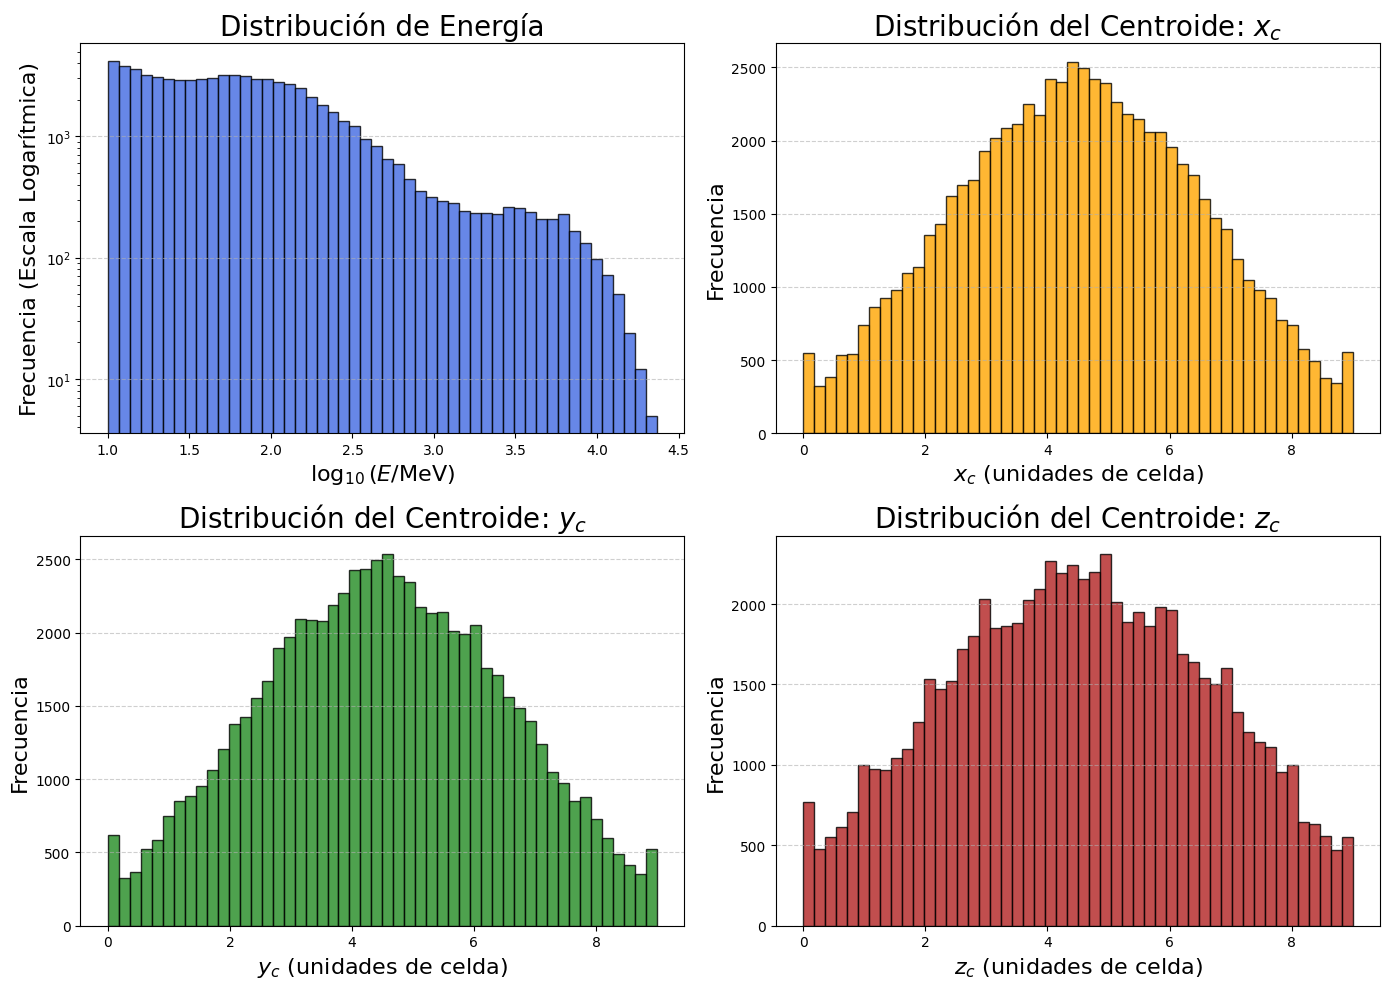

In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el dataset TOTAL
file_path = "Dataset_Total.pt"
data = torch.load(file_path, map_location="cpu")

targets = data["targets"].numpy()

# 2. Extraer las variables objetivo puras (0 a 9 unidades de celda)
log_E = targets[:, 0]
x_c = targets[:, 1]
y_c = targets[:, 2]
z_c = targets[:, 3]

# 3. Graficar las distribuciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
axes = axes.flatten()

# Histograma de Energía 
axes[0].hist(log_E, bins=50, color='royalblue', edgecolor='black', alpha=0.8, log=True, label='Dataset Total (Núcleo + Corona)')
axes[0].set_title('Distribución de Energía', fontsize=20)
axes[0].set_xlabel(r'$\log_{10}(E/\mathrm{MeV})$', fontsize=16)
axes[0].set_ylabel('Frecuencia (Escala Logarítmica)', fontsize=16)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)


# Histogramas de Centroides
coords = [(x_c, r'$x_c$', 'orange'), 
          (y_c, r'$y_c$', 'forestgreen'), 
          (z_c, r'$z_c$', 'firebrick')]

for i, (coord_data, label, color) in enumerate(coords, start=1):
    axes[i].hist(coord_data, bins=50, color=color, edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribución del Centroide: {label}', fontsize=20)
    axes[i].set_xlabel(f'{label} (unidades de celda)', fontsize=16)
    axes[i].set_ylabel('Frecuencia', fontsize=16)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

# Exportar
plt.savefig("distribucion_variables_total.png", dpi=300, bbox_inches='tight')
plt.savefig("distribucion_variables_total.pdf", bbox_inches='tight')

plt.show()

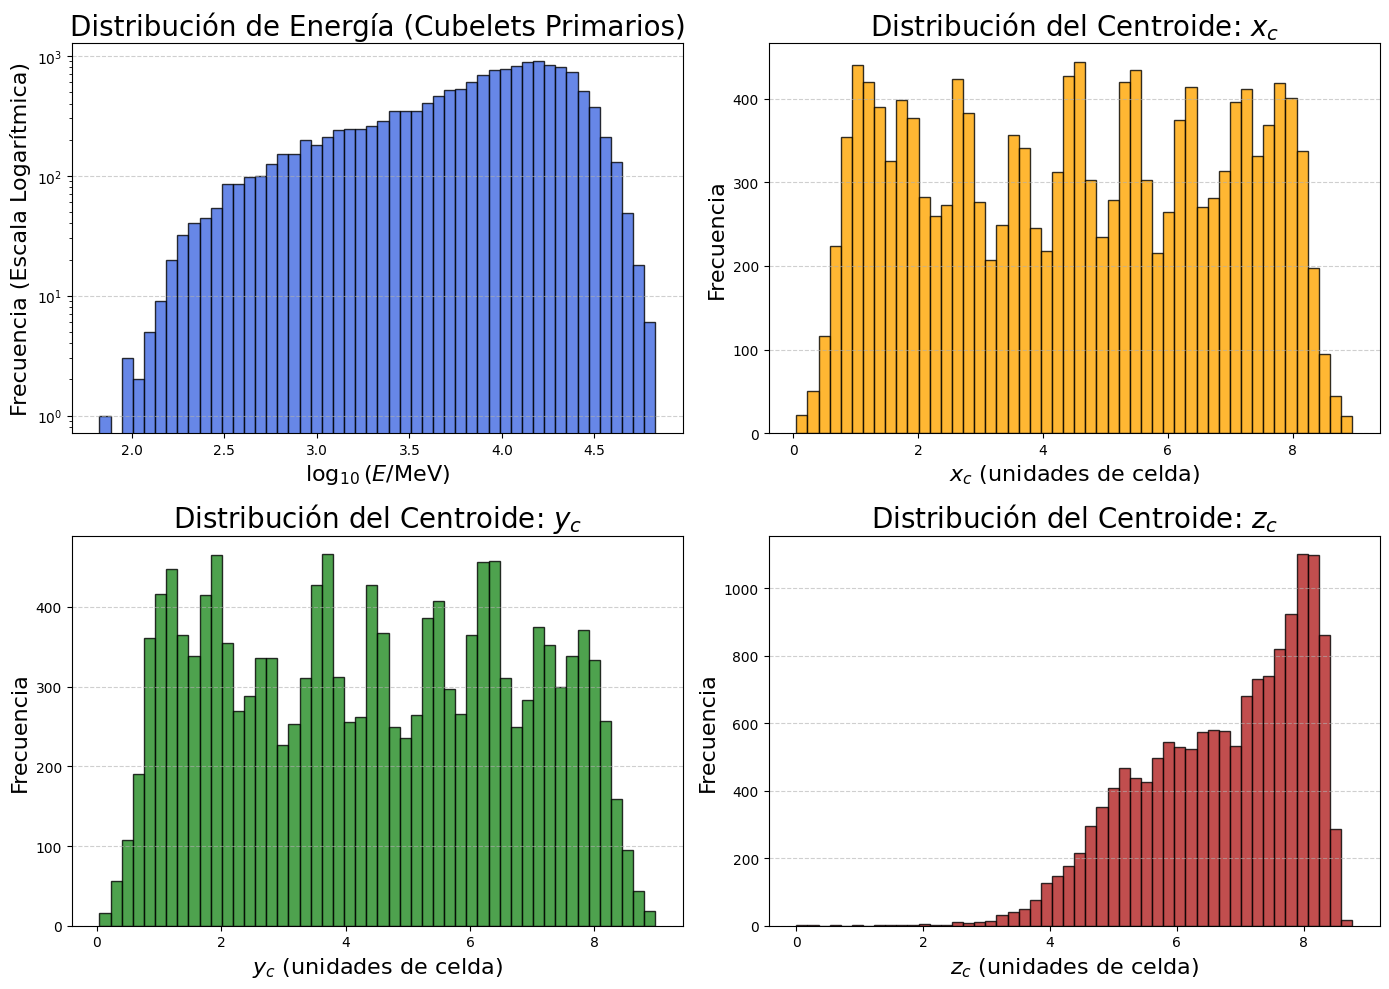

In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el dataset FILTRADO (Solo el vértice primario)
file_path = "Dataset_PrimaryCore.pt"
data = torch.load(file_path, map_location="cpu")

targets = data["targets"].numpy()

# 2. Extraer las variables objetivo puras (0 a 9 unidades de celda)
log_E = targets[:, 0]
x_c = targets[:, 1]
y_c = targets[:, 2]
z_c = targets[:, 3]

# 3. Graficar las distribuciones del núcleo
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
axes = axes.flatten()

# Histograma de Energía
axes[0].hist(log_E, bins=50, color='royalblue', edgecolor='black', alpha=0.8, log=True, label='Cubelet Principal')
axes[0].set_title('Distribución de Energía (Cubelets Primarios)', fontsize=20)
axes[0].set_xlabel(r'$\log_{10}(E/\mathrm{MeV})$', fontsize=16)
axes[0].set_ylabel('Frecuencia (Escala Logarítmica)', fontsize=16)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)


# Histogramas de Centroides
coords = [(x_c, r'$x_c$', 'orange'), 
          (y_c, r'$y_c$', 'forestgreen'), 
          (z_c, r'$z_c$', 'firebrick')]

for i, (coord_data, label, color) in enumerate(coords, start=1):
    axes[i].hist(coord_data, bins=50, color=color, edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribución del Centroide: {label}', fontsize=20)
    axes[i].set_xlabel(f'{label} (unidades de celda)', fontsize=16)
    axes[i].set_ylabel('Frecuencia', fontsize=16)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

# Exportar
plt.savefig("distribucion_variables_primary_core.png", dpi=300, bbox_inches='tight')
plt.savefig("distribucion_variables_primary_core.pdf", bbox_inches='tight')

plt.show()

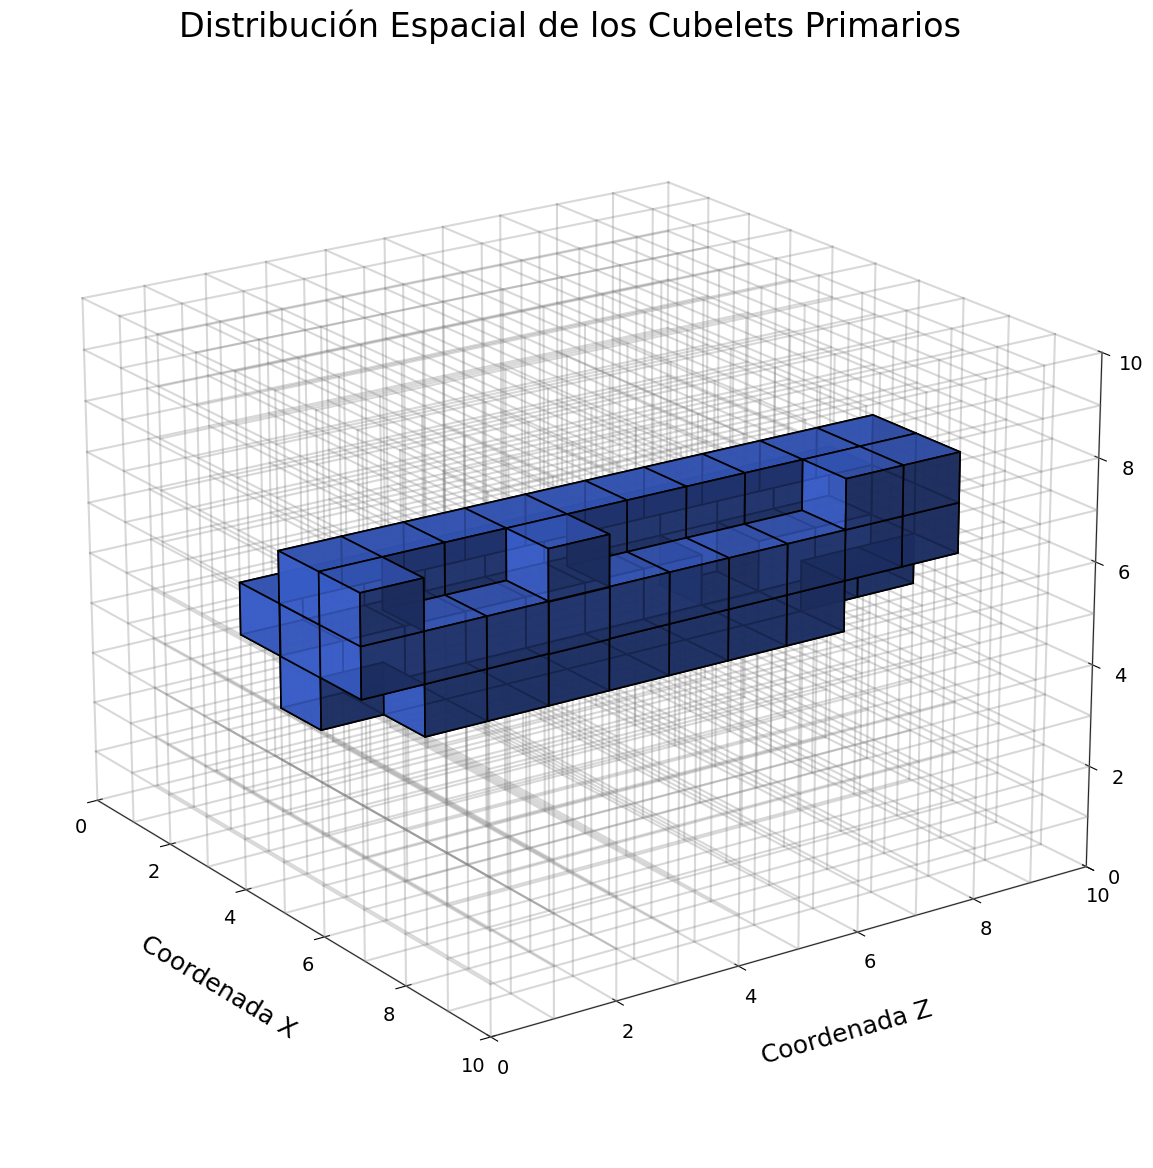

In [45]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Cargar el dataset del núcleo primario
file_path = "Dataset_PrimaryCore.pt"
data = torch.load(file_path, map_location="cpu")
cubelets = data["cubelets"].numpy()

# 2. Decodificar el ID global a coordenadas físicas originales (X, Y, Z)
z_idx = cubelets // 100
y_idx = (cubelets % 100) // 10
x_idx = cubelets % 10

# 3. Reorientación de ejes (Intercambio X y Z):
grid_size = 10
filled = np.zeros((grid_size, grid_size, grid_size), dtype=bool)

# Filtro binario: asignamos True a la posición transformada [X, Z, Y]
for x, y, z in zip(x_idx, y_idx, z_idx):
    filled[x, z, y] = True

# 4. Configurar el color
facecolors = np.zeros(filled.shape + (4,))
facecolors[filled] = [0.25, 0.41, 0.88, 0.85] # Azul royal, casi opaco

# 5. Dibujar el entorno 3D
fig = plt.figure(figsize=(16, 14), facecolor='white')
ax = fig.add_subplot(111, projection='3d')

# --- ELIMINAR EL GRID Y LOS PANELES DE MATPLOTLIB ---
ax.grid(False) 
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('white')
ax.yaxis.pane.set_edgecolor('white')
ax.zaxis.pane.set_edgecolor('white')
# ----------------------------------------------------

# DIBUJAR LA CUADRÍCULA TRIDIMENSIONAL VACÍA (Wireframe manual)
grosor_linea = 1.5   
opacidad_linea = 0.3 

for i in range(grid_size + 1):
    for j in range(grid_size + 1):
        ax.plot([i, i], [j, j], [0, grid_size], color='gray', alpha=opacidad_linea, linewidth=grosor_linea)
        ax.plot([i, i], [0, grid_size], [j, j], color='gray', alpha=opacidad_linea, linewidth=grosor_linea)
        ax.plot([0, grid_size], [i, i], [j, j], color='gray', alpha=opacidad_linea, linewidth=grosor_linea)

# Renderizar EXCLUSIVAMENTE los voxeles activos sobre la cuadrícula
ax.voxels(filled, facecolors=facecolors, edgecolors='black', linewidth=1.2)

# --- AJUSTE DE TAMAÑO DE TEXTOS ---
# Etiquetas de los ejes
ax.set_xlabel('Coordenada X', labelpad=25, fontsize=18)
ax.set_ylabel('Coordenada Z', labelpad=25, fontsize=18)
ax.set_zlabel('Coordenada Y', labelpad=25, fontsize=18)

# Título
ax.set_title('Distribución Espacial de los Cubelets Primarios', fontsize=24, y=1.08)

# Números de los ejes (tick labels)
ax.tick_params(axis='both', which='major', labelsize=14)

# Forzar los límites exactos de la matriz
ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.set_zlim(0, grid_size)

# Ajustar el ángulo de cámara
ax.view_init(elev=20, azim=-35)

# Márgenes para evitar recortes
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.9)

# Exportar
plt.savefig("distribucion_3D_primaria_rejilla.pdf", bbox_inches='tight', pad_inches=1.0)
plt.savefig("distribucion_3D_primaria_rejilla.png", dpi=300, bbox_inches='tight', pad_inches=1.0)

plt.show()

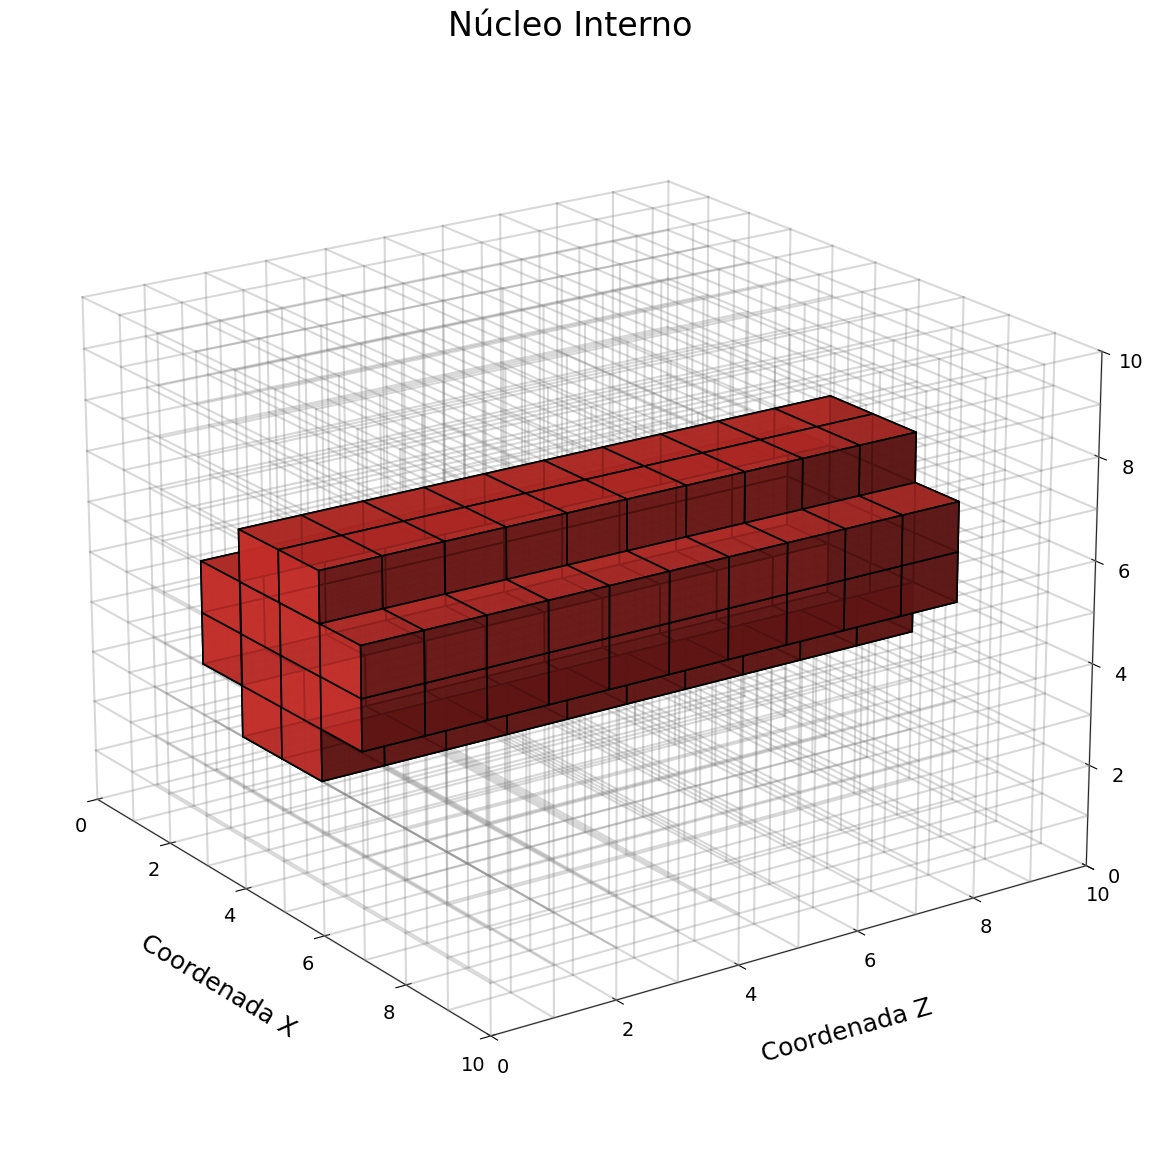

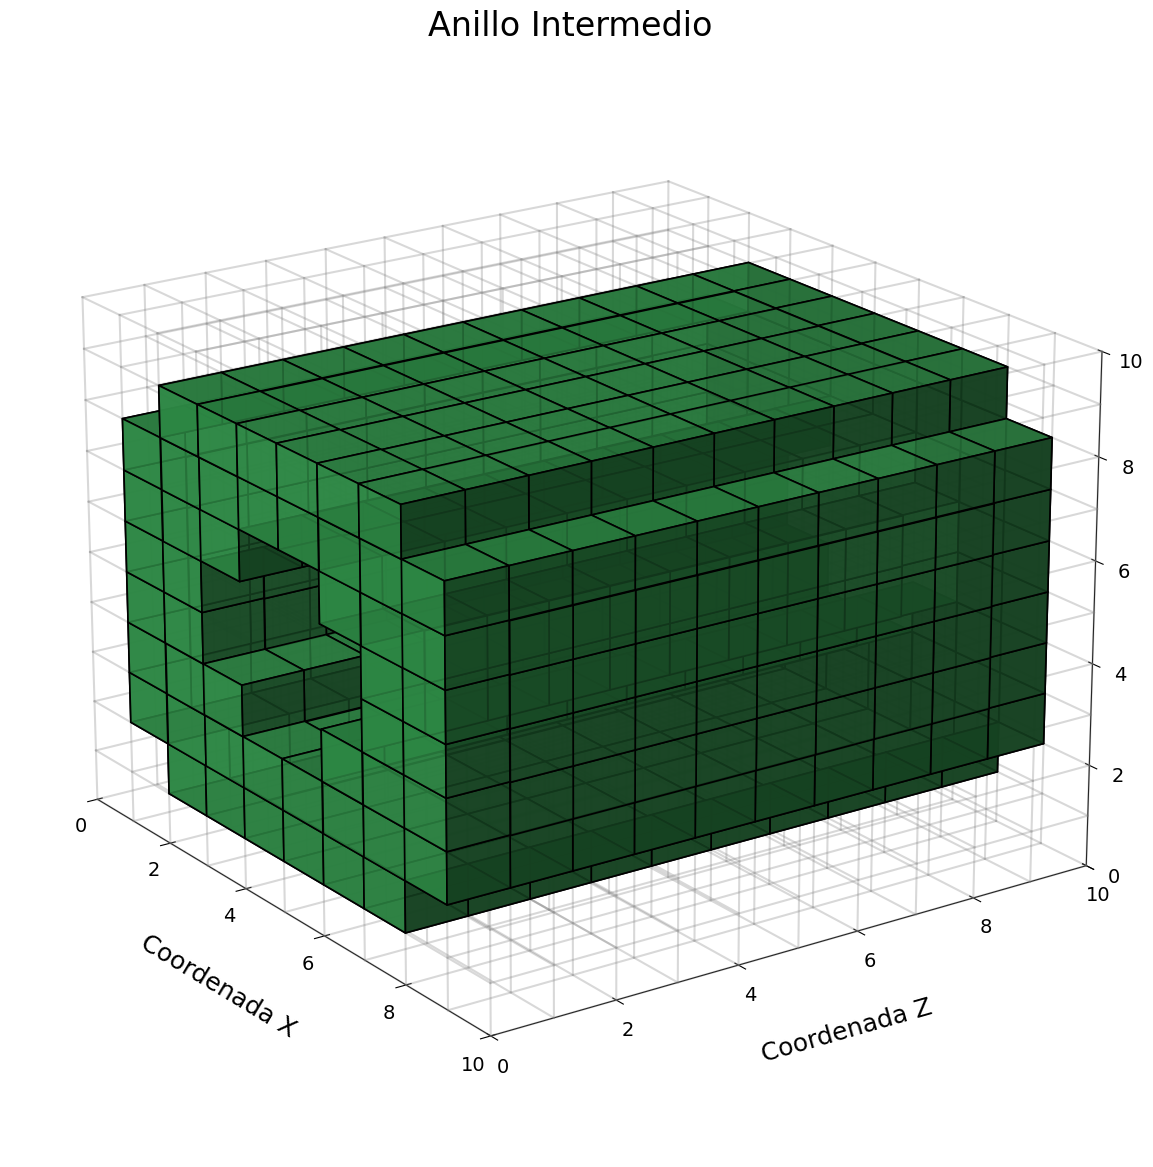

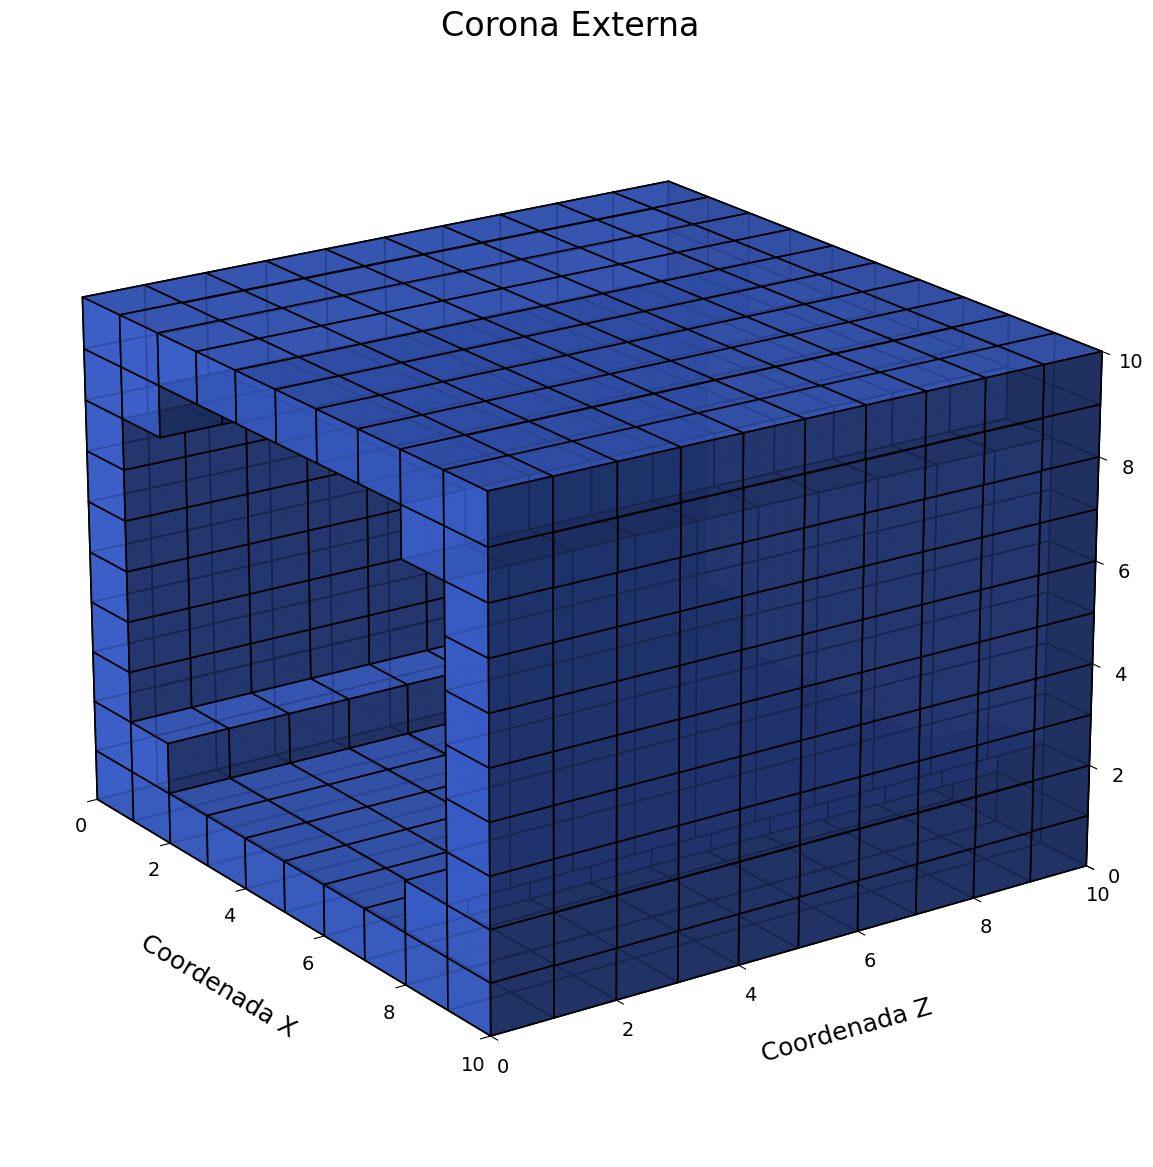

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Definimos las tres regiones radiales y sus colores (RGBA)
regiones = [
    {
        "nombre": "Núcleo Interno",
        "condicion": lambda r: r < 2,
        "color": [0.86, 0.20, 0.18, 0.85], # Rojo oscuro (fuego/alta energía)
        "archivo": "seccion_radial_interna"
    },
    {
        "nombre": "Anillo Intermedio",
        "condicion": lambda r: (r >= 2) & (r < 4.5),
        "color": [0.20, 0.60, 0.30, 0.85], # Verde bosque
        "archivo": "seccion_radial_media"
    },
    {
        "nombre": "Corona Externa",
        "condicion": lambda r: r >= 4.5,
        "color": [0.25, 0.41, 0.88, 0.85], # Azul royal (dispersión baja energía)
        "archivo": "seccion_radial_externa"
    }
]

grid_size = 10
# El centro geométrico de una cuadrícula de 0 a 9 está exactamente en 4.5
centro_x, centro_y = 4.5, 4.5

for region in regiones:
    # 1. Crear el filtro booleano vacío
    filled = np.zeros((grid_size, grid_size, grid_size), dtype=bool)
    
    # 2. Calcular qué voxeles caen dentro de este radio
    for x in range(grid_size):
        for y in range(grid_size):
            # Calculamos la distancia transversal 2D
            radio = np.sqrt((x - centro_x)**2 + (y - centro_y)**2)
            
            if region["condicion"](radio):
                # Si cumple el radio, activamos toda la profundidad Z (de 0 a 9)
                for z in range(grid_size):
                    # Recordamos el mapeo: [X, Z, Y]
                    filled[x, z, y] = True

    # 3. Asignar el color
    facecolors = np.zeros(filled.shape + (4,))
    facecolors[filled] = region["color"]

    # 4. Configurar la figura
    fig = plt.figure(figsize=(16, 14), facecolor='white')
    ax = fig.add_subplot(111, projection='3d')

    # Eliminar el grid de fondo de matplotlib
    ax.grid(False) 
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('white')
    ax.yaxis.pane.set_edgecolor('white')
    ax.zaxis.pane.set_edgecolor('white')

    # Dibujar el Wireframe (los 1000 huecos de referencia)
    grosor_linea = 1.5   
    opacidad_linea = 0.3 
    for i in range(grid_size + 1):
        for j in range(grid_size + 1):
            ax.plot([i, i], [j, j], [0, grid_size], color='gray', alpha=opacidad_linea, linewidth=grosor_linea)
            ax.plot([i, i], [0, grid_size], [j, j], color='gray', alpha=opacidad_linea, linewidth=grosor_linea)
            ax.plot([0, grid_size], [i, i], [j, j], color='gray', alpha=opacidad_linea, linewidth=grosor_linea)

    # Renderizar los voxeles correspondientes a la máscara
    ax.voxels(filled, facecolors=facecolors, edgecolors='black', linewidth=1.2)

    # Textos y tamaños
    ax.set_xlabel('Coordenada X', labelpad=25, fontsize=18)
    ax.set_ylabel('Coordenada Z', labelpad=25, fontsize=18)
    ax.set_zlabel('Coordenada Y', labelpad=25, fontsize=18)
    ax.set_title(f'{region["nombre"]}', fontsize=24, y=1.08)
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Forzar los límites
    ax.set_xlim(0, grid_size)
    ax.set_ylim(0, grid_size)
    ax.set_zlim(0, grid_size)

    # Perspectiva
    ax.view_init(elev=20, azim=-35)

    # Márgenes seguros
    fig.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.9)

    # Exportar
    nombre_archivo = region["archivo"]
    plt.savefig(f"{nombre_archivo}.pdf", bbox_inches='tight', pad_inches=1.0)
    plt.savefig(f"{nombre_archivo}.png", dpi=300, bbox_inches='tight', pad_inches=1.0)

    # Cerramos la figura para liberar memoria y que salgan las tres de forma independiente
    plt.show()

<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
C:\Users\froil\AppData\Local\Temp\ipykernel_15004\3309123239.py:27: SyntaxWarning: invalid escape sequence '\l'
  labels = ['Núcleo ($E > 1500$ MeV)', 'Intermedio ($150 < E \leq 1500$ MeV)', 'Corona ($E \leq 150$ MeV)']
C:\Users\froil\AppData\Local\Temp\ipykernel_15004\3309123239.py:27: SyntaxWarning: invalid escape sequence '\l'
  labels = ['Núcleo ($E > 1500$ MeV)', 'Intermedio ($150 < E \leq 1500$ MeV)', 'Corona ($E \leq 150$ MeV)']


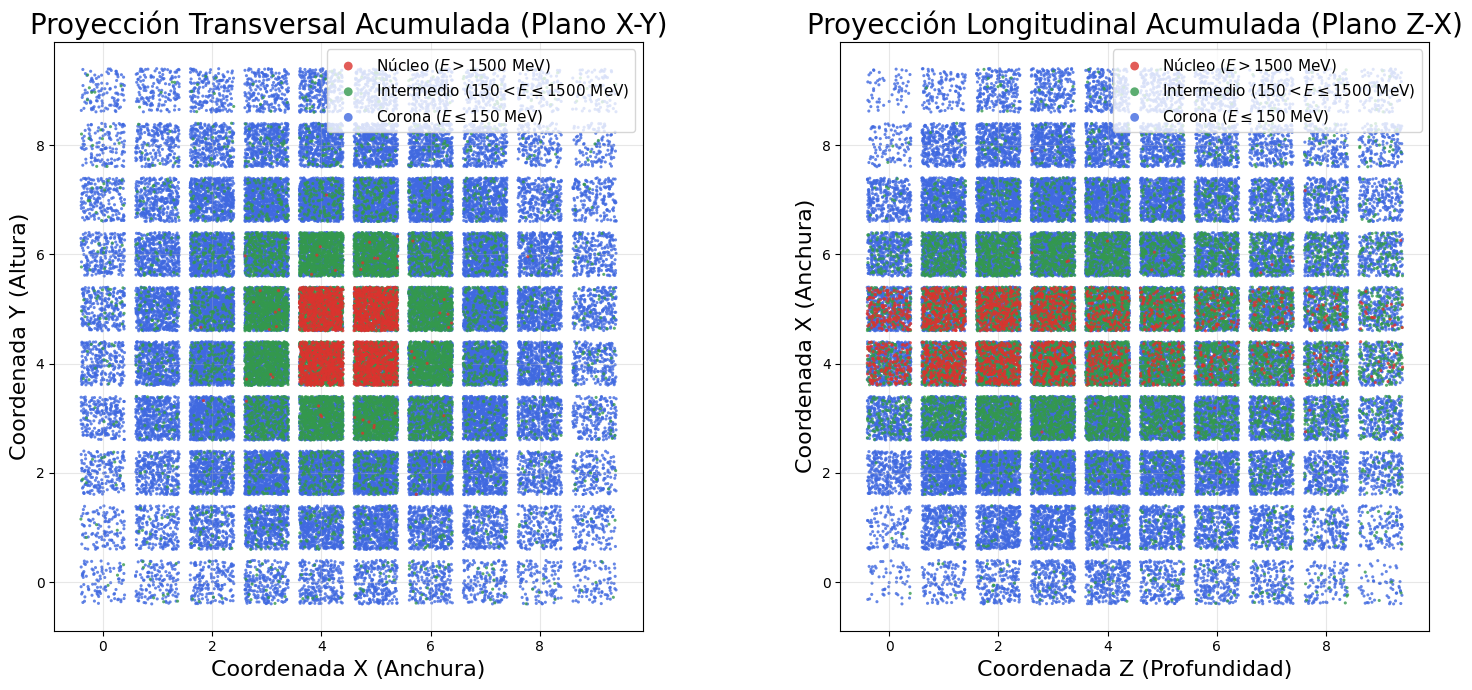

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el dataset TOTAL
file_path = "Dataset_Total.pt"
data = torch.load(file_path, map_location="cpu")

# Extraer coordenadas e intensidad
targets = data["targets"].numpy()
cubelets = data["cubelets"].numpy()

# Desempaquetar ID a coordenadas (0-9)
z_idx = cubelets // 100
y_idx = (cubelets % 100) // 10
x_idx = cubelets % 10

# Revertir log10 para obtener MeV absolutos
E_abs = 10**(targets[:, 0])

# 2. Crear las máscaras de energía para los grupos
grupos = np.zeros_like(E_abs, dtype=int)
grupos[(E_abs <= 1500) & (E_abs > 150)] = 1
grupos[E_abs <= 150] = 2 

colores = ['#db332e', '#33994d', '#4069e0']
labels = ['Núcleo ($E > 1500$ MeV)', 'Intermedio ($150 < E \leq 1500$ MeV)', 'Corona ($E \leq 150$ MeV)']

# 3. Configurar el renderizado
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')
jitter = 0.4
SIZE_VAL = 5
ALPHA_VAL = .8  # Máxima opacidad requerida para evitar pérdida de eventos

# -- A. VISTA FRONTAL (X vs Y) --
# Bucle invertido para dibujar la corona primero y el núcleo por encima (evitando oclusión)
for i in [2, 1, 0]:
    mask = (grupos == i)
    jx = np.random.uniform(-jitter, jitter, size=np.sum(mask))
    jy = np.random.uniform(-jitter, jitter, size=np.sum(mask))
    axes[0].scatter(x_idx[mask] + jx, y_idx[mask] + jy, 
                    c=colores[i], label=labels[i], 
                    s=SIZE_VAL, alpha=ALPHA_VAL, edgecolors='none', zorder=3-i)

axes[0].set_title('Proyección Transversal Acumulada (Plano X-Y)', fontsize=20)
axes[0].set_xlabel('Coordenada X (Anchura)', fontsize=16)
axes[0].set_ylabel('Coordenada Y (Altura)', fontsize=16)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3, zorder=0)

# Reordenar leyenda para mantener coherencia (Núcleo en la parte superior)
handles, labels_leg = axes[0].get_legend_handles_labels()
leg0 = axes[0].legend(handles[::-1], labels_leg[::-1], fontsize=11)
for lh in leg0.legend_handles: 
    lh.set_sizes([40])

# -- B. VISTA LATERAL (Z vs X) --
# Bucle invertido para dibujo topográfico correcto
for i in [2, 1, 0]:
    mask = (grupos == i)
    jz = np.random.uniform(-jitter, jitter, size=np.sum(mask))
    jx = np.random.uniform(-jitter, jitter, size=np.sum(mask))
    axes[1].scatter(z_idx[mask] + jz, x_idx[mask] + jx, 
                    c=colores[i], label=labels[i], 
                    s=SIZE_VAL, alpha=ALPHA_VAL, edgecolors='none', zorder=3-i)

axes[1].set_title('Proyección Longitudinal Acumulada (Plano Z-X)', fontsize=20)
axes[1].set_xlabel('Coordenada Z (Profundidad)', fontsize=16)
axes[1].set_ylabel('Coordenada X (Anchura)', fontsize=16)
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3, zorder=0)

handles1, labels_leg1 = axes[1].get_legend_handles_labels()
leg1 = axes[1].legend(handles1[::-1], labels_leg1[::-1], fontsize=11)
for lh in leg1.legend_handles: 
    lh.set_sizes([40])

plt.tight_layout()

# Exportar
plt.savefig("justificacion_2D_scatter.pdf", bbox_inches='tight')
plt.savefig("justificacion_2D_scatter.png", dpi=300, bbox_inches='tight')

plt.show()

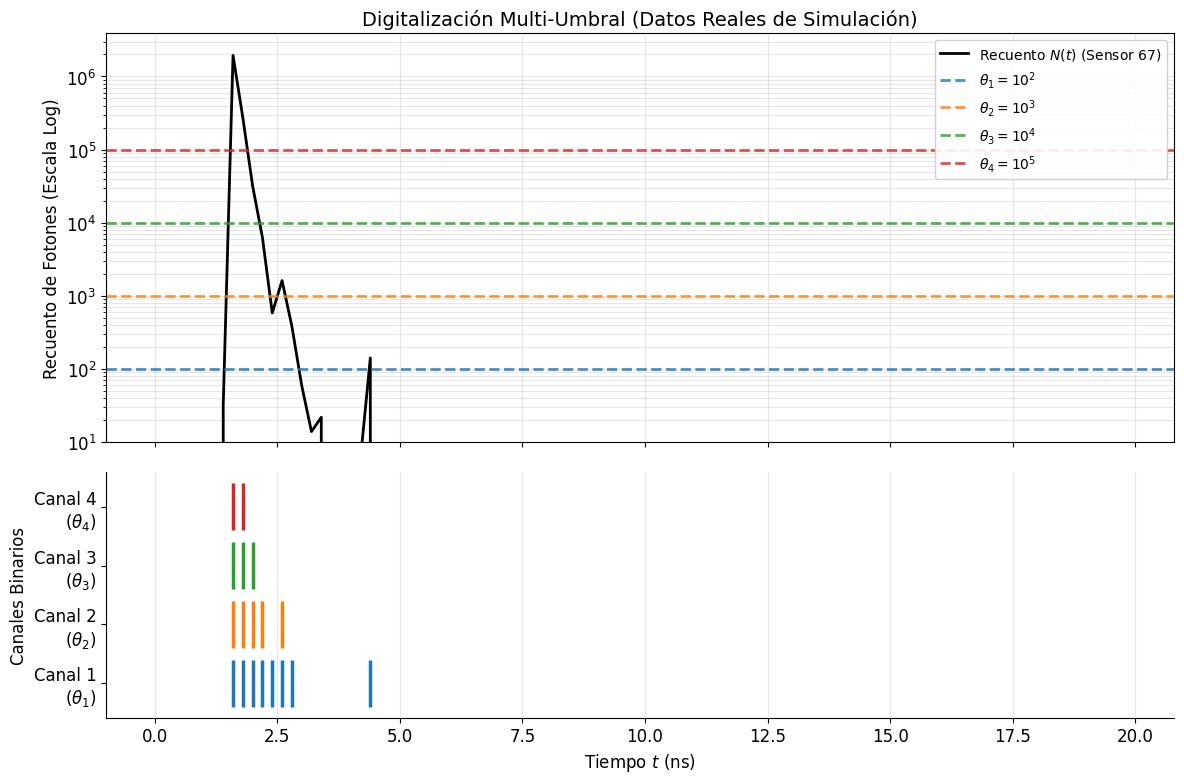

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Configuración de estilo
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10
})

# 1. Cargar el dataset REAL
file_path = "Dataset_PrimaryCore.pt" # <- Cambia esto por tu archivo .pt
data = torch.load(file_path, map_location="cpu")
samples = data["samples"] # Tensor de forma: (N_eventos, 100_bins, 100_sensores)

# 2. Seleccionar el evento más representativo (el de mayor recuento total de fotones)
total_photons_per_event = samples.sum(dim=(1, 2))
best_event_idx = torch.argmax(total_photons_per_event).item()
event_data = samples[best_event_idx] # Forma: (100, 100)

# 3. Seleccionar el sensor individual que recibió más luz en ese evento
total_photons_per_sensor = event_data.sum(dim=0)
best_sensor_idx = torch.argmax(total_photons_per_sensor).item()

# Extraer la serie temporal exacta de ese sensor (100 bins)
signal = event_data[:, best_sensor_idx].numpy()

# Convertir los 100 bins a tiempo físico (Cada bin son 0.2 ns, total 20 ns)
t = np.arange(100) * 0.2 

# 4. Definir los umbrales fijos teóricos (10^2, 10^3, 10^4, 10^5)
multiplicity = 4
thresholds = [10**(i+2) for i in range(multiplicity)]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# 5. Crear figura
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1.2]})
fig.patch.set_facecolor('white')

# --- Panel Superior: Señal Analógica Real ---
ax1.plot(t, signal, color='black', linewidth=2, label=f'Recuento $N(t)$ (Sensor {best_sensor_idx})')

for i, th in enumerate(thresholds):
    ax1.axhline(th, color=colors[i], linestyle='--', linewidth=2, alpha=0.8, 
                label=rf'$\theta_{i+1} = 10^{i+2}$')
    
ax1.set_yscale('log')
# Ajustar el límite inferior para evitar log(0) si hay instantes sin fotones
ax1.set_ylim(10, max(signal.max() * 2, 2*10**5))
ax1.set_ylabel('Recuento de Fotones (Escala Log)')
ax1.set_title('Digitalización Multi-Umbral (Datos Reales de Simulación)')
ax1.legend(loc='upper right', framealpha=0.9)
ax1.grid(True, which="both", alpha=0.3)

# --- Panel Inferior: Trenes de Pulsos Resultantes (Spikes) ---
for i, th in enumerate(thresholds):
    # Condición de Heaviside estricta
    spikes = signal >= th
    spike_times = t[spikes]
    
    # Dibujar raster plot
    if len(spike_times) > 0:
        ax2.vlines(spike_times, i - 0.4, i + 0.4, color=colors[i], linewidth=2.5)

ax2.set_yticks(range(multiplicity))
ax2.set_yticklabels([f'Canal {i+1}\n($\\theta_{i+1}$)' for i in range(multiplicity)])
ax2.set_xlabel('Tiempo $t$ (ns)')
ax2.set_ylabel('Canales Binarios')
ax2.grid(True, axis='x', alpha=0.3)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('codificacion_multiumbral_real.pdf', bbox_inches='tight')
plt.savefig('codificacion_multiumbral_real.png', dpi=300, bbox_inches='tight')
plt.show()